In [17]:
from random import shuffle

import pymatching
import sinter
from typing import List
import os
import numpy as np
import stim
import itertools
import matplotlib.pyplot as plt
import beliefmatching
from numpy import dtype
from numpy.matlib import rand
from stimbposd import SinterDecoder_BPOSD, sinter_decoders
import math
import random
import datetime


print(stim.__version__,os.cpu_count())

1.15.0 12


In [27]:
x = (1,"2",np.zeros(2))
print(x[0],x[2])

1 [0. 0.]


In [24]:
circuit_error_p=[1.0,.9,.8]
p=0.001
n=9

In [33]:
circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=1,
    distance=3,
    after_clifford_depolarization=p*circuit_error_p[0],
    after_reset_flip_probability=p*circuit_error_p[1],
    before_measure_flip_probability=p*circuit_error_p[2]
)
tasks = [
    sinter.Task(
        circuit=circuit
    )
]
circuit

stim.Circuit('''
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(1, 3) 8
    QUBIT_COORDS(2, 2) 9
    QUBIT_COORDS(3, 3) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(5, 3) 12
    QUBIT_COORDS(6, 2) 13
    QUBIT_COORDS(0, 4) 14
    QUBIT_COORDS(1, 5) 15
    QUBIT_COORDS(2, 4) 16
    QUBIT_COORDS(3, 5) 17
    QUBIT_COORDS(4, 4) 18
    QUBIT_COORDS(5, 5) 19
    QUBIT_COORDS(4, 6) 25
    R 1 3 5 8 10 12 15 17 19
    X_ERROR(0.0009) 1 3 5 8 10 12 15 17 19
    R 2 9 11 13 14 16 18 25
    X_ERROR(0.0009) 2 9 11 13 14 16 18 25
    TICK
    H 2 11 16 25
    DEPOLARIZE1(0.001) 2 11 16 25
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    DEPOLARIZE2(0.001) 2 3 16 17 11 12 15 14 10 9 19 18
    TICK
    CX 2 1 16 15 11 10 8 14 3 9 12 18
    DEPOLARIZE2(0.001) 2 1 16 15 11 10 8 14 3 9 12 18
    TICK
    CX 16 10 11 5 25 19 8 9 17 18 12 13
    DEPOLARIZE2(0.001) 16 10 11 5 25 19 8 9 17 18 12 13
    TICK
    CX 16 8 11 3 25 17 1 

In [16]:
f = open("./data/test5.txt","w")
print(1,file=f)
f.close()

In [6]:
print(collected_surface_code_stats)

[sinter.TaskStats(strong_id='935841e60bb8c3f04d5eb7524f44a4fdafd884a49ef68c49199046a20ac23f72', decoder='pymatching', json_metadata=None, shots=10000, errors=1)]


In [34]:
dem = circuit.detector_error_model(flatten_loops=True)

dem[0].target_groups()

[[stim.DemTarget('D0')]]

In [54]:
dem_pred = stim.DetectorErrorModel()
dem_pred.append("error",0.1,[stim.DemTarget.relative_detector_id(0)])
dem_pred

ValueError: Bad target '[stim.DemTarget('D0')]' for instruction 'error'.

In [56]:
dem_pred = stim.DetectorErrorModel()
for instruction in dem.flattened():
    if instruction.type == 'error':
        new_prob = 0.1
            # 获取原指令的目标（探测器、逻辑观测器）
        targets = instruction.targets_copy()
            # 添加新的 error 指令
        dem_pred.append('error', new_prob, targets)
    else:
        dem_pred.append(instruction)
dem_pred

stim.DetectorErrorModel('''
    error(0.1) D0
    error(0.1) D0 D1
    error(0.1) D0 D4
    error(0.1) D1 D2
    error(0.1) D1 D4
    error(0.1) D1 D5
    error(0.1) D1 L0
    error(0.1) D2
    error(0.1) D2 D3
    error(0.1) D2 D4
    error(0.1) D2 D5
    error(0.1) D2 D6
    error(0.1) D3 D5
    error(0.1) D3 D6
    error(0.1) D3 D7
    error(0.1) D3 L0
    error(0.1) D4
    error(0.1) D4 D5
    error(0.1) D5 D6
    error(0.1) D5 L0
    error(0.1) D6
    error(0.1) D6 D7
    error(0.1) D7 L0
    detector(0, 4, 0) D0
    detector(2, 2, 0) D1
    detector(4, 4, 0) D2
    detector(6, 2, 0) D3
    detector(0, 4, 1) D4
    detector(2, 2, 1) D5
    detector(4, 4, 1) D6
    detector(6, 2, 1) D7
''')

In [35]:
H = beliefmatching.detector_error_model_to_check_matrices(dem,allow_undecomposed_hyperedges=True)
print(H.check_matrix.shape)
print(H.observables_matrix.shape)
print(H.check_matrix.toarray())

(8, 23)
(1, 23)
[[1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0]
 [0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1]]


In [32]:
check = H.check_matrix.toarray()
for i in range(163):
    tmp = 0
    for j in range(48):
        tmp += check[j][i]
    if tmp > 2:
        print("err")
        break

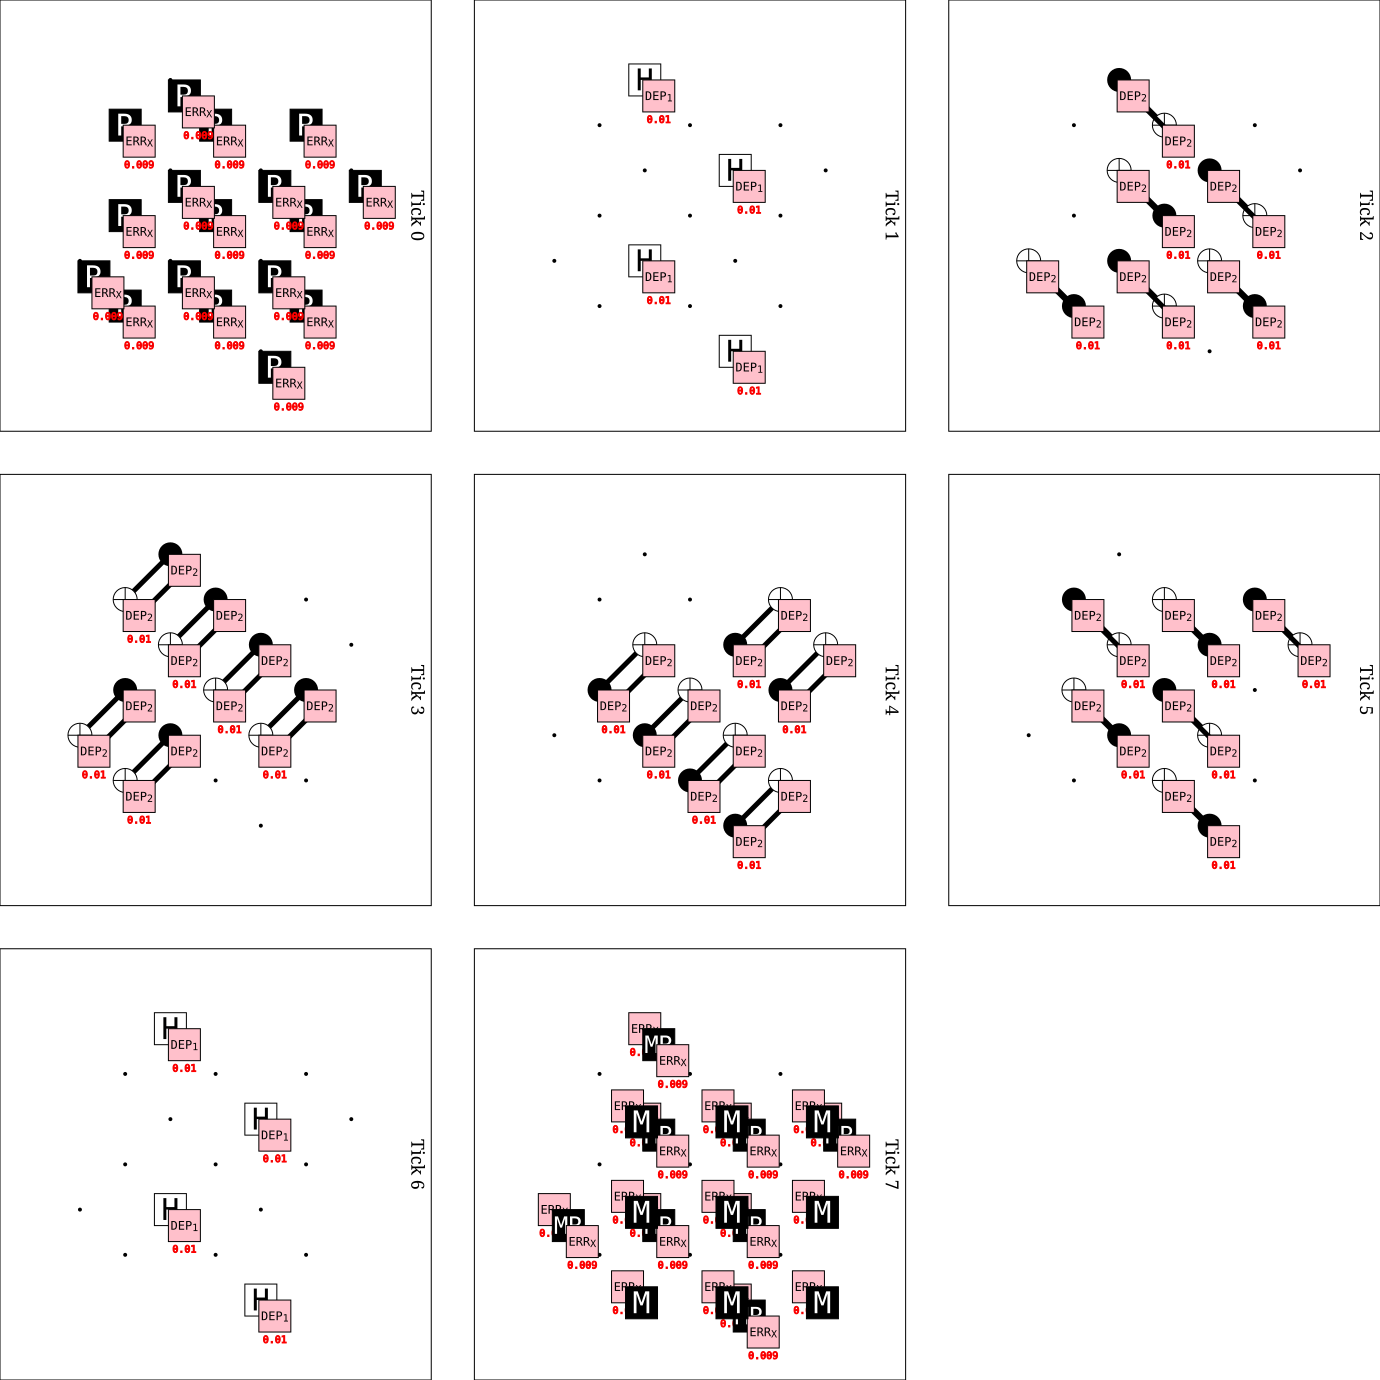

In [56]:
circuit.diagram("timeslice-svg")

In [38]:
collected_surface_code_stats:List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count() - 1,
    tasks=tasks,
    decoders=['bposd'],
    max_shots=1_000_000,
    max_errors=5_0000,
    custom_decoders=sinter_decoders(),
)

In [39]:
# direct sample
print(collected_surface_code_stats)
print(collected_surface_code_stats[0].errors/collected_surface_code_stats[0].shots)

[sinter.TaskStats(strong_id='ba809f2a9eee80383f1e972649dac61137854ab047626acaff92b923b0d44318', decoder='bposd', json_metadata=None, shots=1000000, errors=176, seconds=15.439000001875684)]
0.000176


Above 直接采样

---

In [6]:
def calculate(dem,H,max_order):
    matching = pymatching.Matching.from_detector_error_model(dem)
    K = dem.num_errors
    q =[]
    for i in range(K):
        q.append(dem[i].args_copy()[0])
    q = np.array(q)
    check_matrix = H.check_matrix
    obs_matrix = H.observables_matrix
    prob=.0

    element=np.array([i for i in range(K)])
    for r in range(max_order):
        for comb in itertools.combinations(element,r):
            e = np.array([0] * K,dtype=np.uint8)
            for location in comb:
                e[location] = 1
            syndrome = (check_matrix @ e) %2
            actual_obs = (obs_matrix @ e) %2
            predicted_obs = matching.decode(syndrome, return_observables=True)
            if (not np.equal(actual_obs,predicted_obs)):
                prob += np.prod([q[i] if e[i] else (1-q[i]) for i in range(K)])
    return prob


In [120]:
calculate(dem,H,4)

np.float64(0.00017315987751582627)

Above 直接计算

---

In [33]:
sampler = circuit.compile_detector_sampler()
one_sample = sampler.sample(shots=1,bit_packed=False)[0]
print(one_sample)
M = 8
K = dem.num_errors
delta = 0.2
print(math.log(K/delta)**2)
print(math.log(1/delta)**2)
print(math.log(K))
print(math.log(K/delta)**2 * math.log(1/delta)**2 * math.log(K))
q = int(delta**(-2) * K * max(math.log(K/delta)**2 * math.log(1/delta)**2 * math.log(K),math.log(1/.01)))
print(q)
print(2**K)



[False False False False False False False False]
22.5143809027738
2.5902903939802346
3.1354942159291497
182.85821172705565
105143
8388608


In [60]:
K = dem.num_errors
delta = 0.1
q = int(delta**(-2) * K * max(math.log(K/delta)**2 * math.log(1/delta)**2 * math.log(K),math.log(1/.01)))
print("K=  ",K)
print("q=  ",q)
print("|M|=",2**m)

K=   23
q=   1130723
|M|= 8388608


In [32]:
A = np.zeros((q,K),dtype=np.uint8)
m = np.array([0] * q)
check_matrix = H.check_matrix.toarray()
for i in range(q):
    m[i] = random.randint(1,2**M)
    for j in range(M):
        cur = m[i]
        if (cur & 1):
            A[i] ^= check_matrix[j]
        cur >>=1

In [30]:
sampler = circuit.compile_detector_sampler()
S = 100
sample = sampler.sample(shots=S,bit_packed=False)
sample_int = np.zeros(S,dtype=np.uint8) # attention: only for d = 3
for k in range(S):
    for i,b in enumerate(sample[k]):
        sample_int |= np.uint8(b<<i)
y = np.zeros(q)
for i in range(q):
    parity = 0
    cur = m[i]
    tmp = 0
    for k in range(S):
        tmp += (-1) ** ( (m[i] ^ sample_int[k]).bit_count() & 1)
    y[i] = tmp/S


In [31]:
print(y[2])

-1.0


In [68]:
matching = pymatching.Matching.from_detector_error_model(dem)
predicted_obs = matching.decode(syndrome, return_observables=True)
obs_matrix = H.observables_matrix
actual_obs = (obs_matrix @ e) %2
print(obs_matrix)
print(actual_obs)
print(predicted_obs)

<Compressed Sparse Column sparse matrix of dtype 'uint8'
	with 4 stored elements and shape (1, 23)>
  Coords	Values
  (0, 6)	1
  (0, 15)	1
  (0, 19)	1
  (0, 22)	1
[1]
[0]


In [61]:
sampler = circuit.compile_detector_sampler()
sample = sampler.sample(shots=10,bit_packed=False)

print(sample)

[[False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False  True False False False False False False]
 [False False False False False False False False]]


In [160]:
check_matrix = H.check_matrix.toarray()
check_matrix[1]

array([0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0], dtype=uint8)

In [35]:
(-1) ** 0

1

In [6]:
def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
    sampler = circuit.compile_detector_sampler()
    detection_events, observable_flips = sampler.sample(num_shots,separate_observables=True)

    detector_error_model = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)
    predictions = matcher.decode_batch(detection_events)

    num_errors = 0
    for shot in range(num_shots):
        actual_for_shot = observable_flips[shot]
        predictions_for_shot = predictions[shot]
        if not np.array_equal(actual_for_shot,predictions_for_shot):
            num_errors += 1
    return num_errors

In [73]:
# sample

num_shots=100_00

In [11]:

num_logical_errors = count_logical_errors(circuit,num_shots)
print("there were", num_logical_errors, "wrong predictions (logical errors) out of", num_shots, "shots")
print("p_fail=",num_logical_errors/num_shots)

# 60s in total for 1e5 shots

there were 0 wrong predictions (logical errors) out of 10000000 shots
p_fail= 0.0


In [80]:
tasks = [
    sinter.Task(
        circuit=circuit,
        json_metadata={"d":[5],"p":[p]}
    )
]

collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count()-1,
    tasks=tasks,
    decoders=["pymatching"],
    max_shots=num_shots,
    max_errors=500
)
# time reduced to 4s

In [81]:
print(collected_stats)
print(type(collected_stats))
print("logical error rate:",collected_stats[0].errors/collected_stats[0].shots)

[sinter.TaskStats(strong_id='e86ef2b1bf3b1fe54d76afe5ef4e6c492464dfff2fde7e504dfa0026231fa960', decoder='pymatching', json_metadata={'d': [5], 'p': [0.01]}, shots=10000, errors=1, seconds=0.031000000017229468)]
<class 'list'>
logical error rate: 0.0001


In [82]:
d = 5

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    rounds=1,
    distance=3,
    before_round_data_depolarization=p
)

circuit

stim.Circuit('''
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(1, 3) 8
    QUBIT_COORDS(2, 2) 9
    QUBIT_COORDS(3, 3) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(5, 3) 12
    QUBIT_COORDS(6, 2) 13
    QUBIT_COORDS(0, 4) 14
    QUBIT_COORDS(1, 5) 15
    QUBIT_COORDS(2, 4) 16
    QUBIT_COORDS(3, 5) 17
    QUBIT_COORDS(4, 4) 18
    QUBIT_COORDS(5, 5) 19
    QUBIT_COORDS(4, 6) 25
    R 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
    TICK
    DEPOLARIZE1(0.01) 1 3 5 8 10 12 15 17 19
    H 2 11 16 25
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    TICK
    CX 2 1 16 15 11 10 8 14 3 9 12 18
    TICK
    CX 16 10 11 5 25 19 8 9 17 18 12 13
    TICK
    CX 16 8 11 3 25 17 1 9 10 18 5 13
    TICK
    H 2 11 16 25
    TICK
    MR 2 9 11 13 14 16 18 25
    DETECTOR(0, 4, 0) rec[-4]
    DETECTOR(2, 2, 0) rec[-7]
    DETECTOR(4, 4, 0) rec[-2]
    DETECTOR(6, 2, 0) rec[-5]
    M 1 3 5 8 10 12 15 17 19
    DETECTOR(0, 4, 1

In [84]:
sampler = circuit.compile_sampler()
print(sampler.sample(1))

[[ True False  True False False False False False  True False  True False
   True  True False False False]]


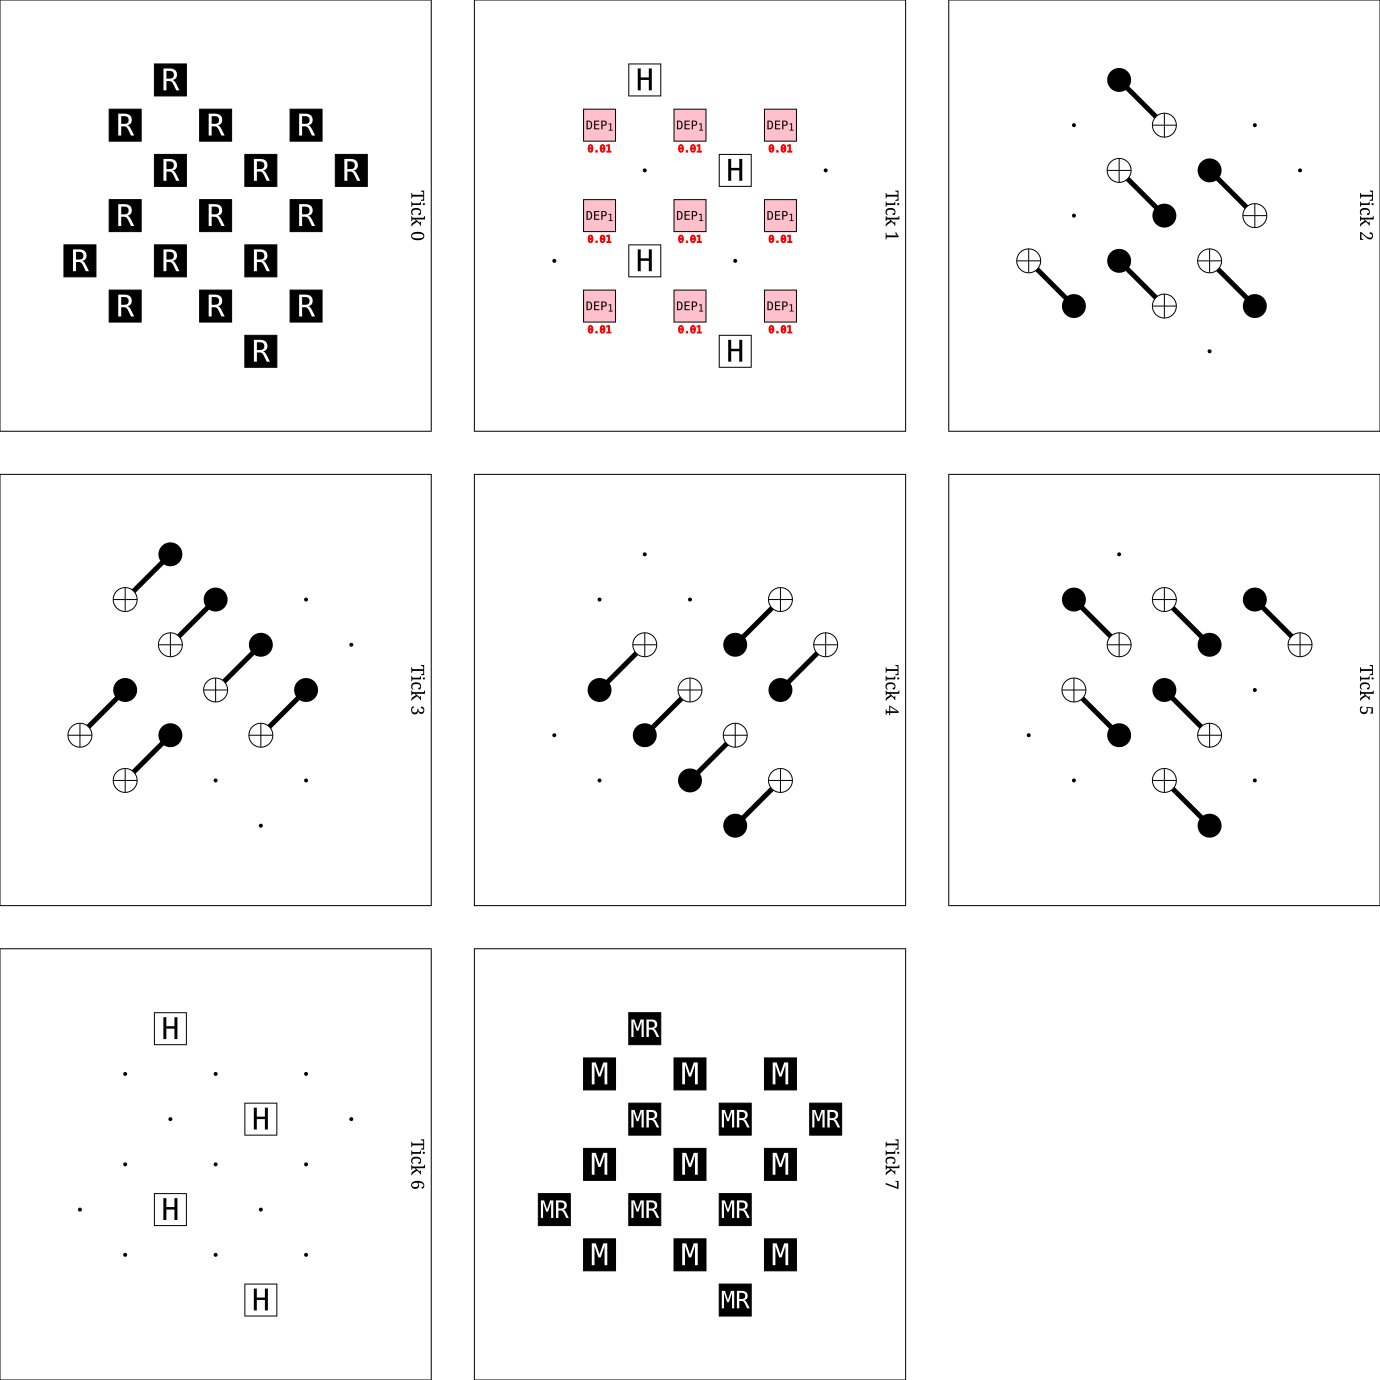

In [85]:
circuit.diagram("timeslice-svg")

---

神经网络测试

In [4]:
import torch
import numpy as np

def generate_data(num_graphs, num_nodes, edge_index, node_weight_range=(0,1), noise_std=0.05):
    """
    生成多个图实例。
    边权重的生成规则（示例）：边权重 = 两端节点权重的平均值 + 高斯噪声。
    实际应用中，你可以替换为任何真实规则。
    """
    node_weights_list = []
    edge_weights_list = []

    for _ in range(num_graphs):
        # 随机生成节点权重 (num_nodes, 1)
        node_weights = torch.FloatTensor(num_nodes, 1).uniform_(*node_weight_range)
        # 计算每条边的权重（示例规则）
        src, dst = edge_index
        true_edge_weights = (node_weights[src] + node_weights[dst]).squeeze() / 2.0
        true_edge_weights += torch.randn_like(true_edge_weights) * noise_std  # 添加噪声
        true_edge_weights = torch.clamp(true_edge_weights, 0, 1)  # 限制范围

        node_weights_list.append(node_weights)
        edge_weights_list.append(true_edge_weights)

    return node_weights_list, edge_weights_list

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class EdgeWeightPredictor(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim=1):
        super().__init__()
        # 两层GCN
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        # 边预测MLP
        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x, edge_index):
        # x: (N, in_dim)
        # edge_index: (2, E)
        tmp = self.conv1(x, edge_index)
        h = F.relu(tmp)
        h = F.relu(self.conv2(h, edge_index))  # (N, hidden_dim)

        # 获取每条边的两端嵌入
        row, col = edge_index
        edge_emb = torch.cat([h[row], h[col]], dim=1)  # (E, hidden_dim*2)
        edge_weight = self.edge_mlp(edge_emb).squeeze()  # (E,)
        return edge_weight

In [13]:

N = 5
edge_index = torch.tensor([[0,1,1,2,2,3,3,4],
                           [1,0,2,1,3,2,4,3]], dtype=torch.long)
test_node_weights, test_edge_weights = generate_data(4, N, edge_index)
print(test_node_weights, test_edge_weights)
print(edge_index)
train_data_list = build_pyg_graphs(test_node_weights, test_edge_weights, edge_index)
train_loader = DataLoader(train_data_list,batch_size = 2,shuffle = False)

[tensor([[0.9288],
        [0.1272],
        [0.6521],
        [0.9283],
        [0.0222]]), tensor([[0.7962],
        [0.2488],
        [0.3766],
        [0.1769],
        [0.3874]]), tensor([[0.0137],
        [0.6442],
        [0.6072],
        [0.1712],
        [0.9676]]), tensor([[0.4886],
        [0.4589],
        [0.6409],
        [0.0157],
        [0.3995]])] [tensor([0.5848, 0.5975, 0.3991, 0.4063, 0.7476, 0.8021, 0.4723, 0.4741]), tensor([0.5431, 0.4968, 0.2465, 0.2959, 0.2304, 0.2276, 0.3293, 0.3002]), tensor([0.3503, 0.3264, 0.6225, 0.6300, 0.3725, 0.4405, 0.6171, 0.6127]), tensor([0.4614, 0.5342, 0.4994, 0.5617, 0.3596, 0.3296, 0.2634, 0.2279])]
tensor([[0, 1, 1, 2, 2, 3, 3, 4],
        [1, 0, 2, 1, 3, 2, 4, 3]])


In [10]:
from torch_geometric.data import HeteroData, Data, DataLoader
from torch_geometric.loader import DataLoader

In [11]:
def build_pyg_graphs(node_weights_list, edge_weights_list, edge_index):
    """将每个实例转换为 PyG Data 对象，边权重作为 y_edge 属性"""
    data_list = []
    for nw, ew in zip(node_weights_list, edge_weights_list):
        data = Data(x=nw, edge_index=edge_index, y_edge=ew)
        data_list.append(data)
    return data_list

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"
model = EdgeWeightPredictor(in_dim=1, hidden_dim=32).to(device)
edge_index = edge_index.to(device)

for batch in train_loader:
    print(batch.x,batch.y_edge)
    print(model(batch.x, batch.edge_index).cpu())

tensor([[0.9288],
        [0.1272],
        [0.6521],
        [0.9283],
        [0.0222],
        [0.7962],
        [0.2488],
        [0.3766],
        [0.1769],
        [0.3874]]) tensor([0.5848, 0.5975, 0.3991, 0.4063, 0.7476, 0.8021, 0.4723, 0.4741, 0.5431,
        0.4968, 0.2465, 0.2959, 0.2304, 0.2276, 0.3293, 0.3002])
tensor([-0.0245, -0.0207, -0.0219, -0.0232, -0.0212, -0.0234, -0.0200, -0.0247,
        -0.0224, -0.0222, -0.0202, -0.0244, -0.0202, -0.0236, -0.0204, -0.0225],
       grad_fn=<SqueezeBackward0>)
tensor([[0.0137],
        [0.6442],
        [0.6072],
        [0.1712],
        [0.9676],
        [0.4886],
        [0.4589],
        [0.6409],
        [0.0157],
        [0.3995]]) tensor([0.3503, 0.3264, 0.6225, 0.6300, 0.3725, 0.4405, 0.6171, 0.6127, 0.4614,
        0.5342, 0.4994, 0.5617, 0.3596, 0.3296, 0.2634, 0.2279])
tensor([-0.0246, -0.0196, -0.0246, -0.0201, -0.0242, -0.0208, -0.0212, -0.0237,
        -0.0231, -0.0213, -0.0211, -0.0233, -0.0197, -0.0248, -0.0197, -

In [92]:
f = open("./data/2026-04-20-x10000.txt",'r')
o = open("./data/2026-04-20-a10000.txt",'w')
for i in range(9999):
    x = f.readline()
    y = f.readline()
    z = (x.rstrip()+y).split()
    if z[9] == ']':
        del z[9]
    z[1] = z[1][1:]
    z[8] = z[8][:-1]
    z[9] = z[9][1:]
    z[-1] = z[-1][:-1]
    for j in range(9,9+23):
        z[j] = z[j][:-1]
    for j in range(1+8+23):
        print(z[j],file=o,end=" ")
    print(end="\n",file=o)
f.close()
o.close()

In [78]:
19998/2

9999.0

In [103]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # 定义神经网络的层
        self.fc1 = nn.Linear(2, 4)  # 输入层有 2 个特征，隐藏层有 4 个神经元
        self.fc2 = nn.Linear(4, 1)  # 隐藏层输出到 1 个神经元（用于二分类）
        self.sigmoid = nn.Sigmoid()  # 二分类激活函数

    def forward(self, x):
        print(x)
        x = torch.relu(self.fc1(x))  # 使用 ReLU 激活函数
        x = self.sigmoid(self.fc2(x))  # 输出层使用 Sigmoid 激活函数
        return x

# 实例化模型
model = SimpleNN()


In [104]:
data = data = torch.randn(2, 2)
outputs = model(data)
print(outputs)

tensor([[ 2.1790, -2.0799],
        [ 1.1710, -2.1093]])
tensor([[0.7910],
        [0.7565]], grad_fn=<SigmoidBackward>)


In [22]:
f = open("./tmp",'r')
z=[]
for i in range(99):
    x,y=f.readline().split()
    z.append(abs(float(x) - float(y))/float(y))
f.close()

In [34]:
import matplotlib.pyplot as plt

[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]


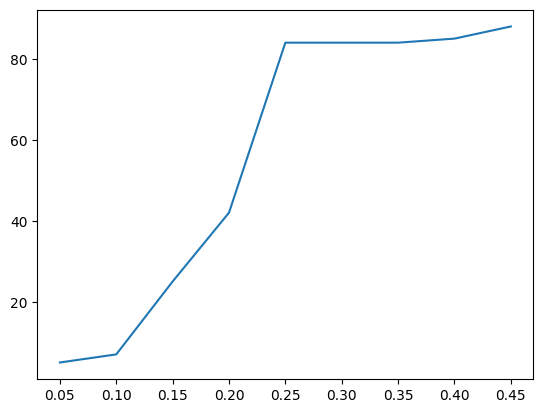

In [36]:
x=[i/20 for i in range(1,10)]
y=[]
print(x)
for xx in x:
    tot = 0
    for i in range(99):
        if z[i] < xx:
            tot +=1
    y.append(tot)
plt.plot(x,y)